## Library include

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings('ignore')

# Display plots inline
%matplotlib inline

## Data preprocessing

### Merge Air Quality and Weather Data (Daily)

In [ ]:
import pandas as pd
import numpy as np

# Helper function to parse dates
def parse_date(date_str):
    return pd.to_datetime(date_str, format='%A, %d %B %Y', errors='coerce')

# Load and aggregate air quality data
def load_and_aggregate_air_quality(year):
    try:
        air_df = pd.read_csv(f'Dhaka_PM2.5_{year}.csv')
        print(f"Loaded Dhaka_PM2.5_{year}.csv: {len(air_df)} rows")
        # Filter for valid data
        if 'QC Name' in air_df.columns:
            air_df = air_df[air_df['QC Name'] == 'Valid']
            print(f"After QC filter, {year}: {len(air_df)} rows")
        # Parse date
        air_df['Date'] = parse_date(air_df['Date (LT)'])
        if air_df['Date'].isnull().all():
            print(f"Invalid dates in air quality file for {year}. Skipping.")
            return None
        # Aggregate to daily
        numeric_cols = ['NowCast Conc.', 'Raw Conc.', 'AQI']
        daily_air_df = air_df.groupby(air_df['Date'].dt.date)[numeric_cols].mean().reset_index()
        daily_air_df['Date'] = pd.to_datetime(daily_air_df['Date'])
        daily_air_df['Year'] = daily_air_df['Date'].dt.year
        print(f"After aggregation, {year}: {len(daily_air_df)} rows")
        return daily_air_df
    except FileNotFoundError:
        print(f"Air quality file for {year} not found. Skipping.")
        return None
    except Exception as e:
        print(f"Error processing air quality file for {year}: {e}")
        return None

# Load weather data
def load_weather(year):
    try:
        weather_df = pd.read_csv(f'HSI{year}.csv')
        print(f"Loaded HSI{year}.csv: {len(weather_df)} rows")
        # Parse date
        weather_df['Date'] = pd.to_datetime(weather_df['DATE'], format='%d/%m/%Y', errors='coerce')
        if weather_df['Date'].isnull().all():
            print(f"Invalid dates in weather file for {year}. Skipping.")
            return None
        # Select relevant columns, excluding PRCP
        weather_cols = ['Date', 'TEMP', 'DEWP', 'VISIB', 'WDSP', 'MXSPD', 'MAX', 'MIN']
        weather_df = weather_df[weather_cols]
        # Replace invalid values
        weather_df = weather_df.replace(9999.9, np.nan)
        print(f"After cleaning, weather {year}: {len(weather_df)} rows")
        return weather_df
    except FileNotFoundError:
        print(f"Weather file for {year} not found. Skipping.")
        return None
    except Exception as e:
        print(f"Error processing weather file for {year}: {e}")
        return None

# Merge air quality and weather data for a year
def merge_air_weather_year(year):
    air_df = load_and_aggregate_air_quality(year)
    weather_df = load_weather(year)
    if air_df is not None and weather_df is not None:
        merged_df = pd.merge(air_df, weather_df, on='Date', how='inner')
        print(f"After merge, {year}: {len(merged_df)} rows")
        # Drop rows with missing values
        merged_df = merged_df.dropna()
        print(f"After dropping NA, {year}: {len(merged_df)} rows")
        return merged_df if not merged_df.empty else None
    return None

# Merge data for all years
years = range(2016, 2023)
merged_dfs = []
for year in years:
    df = merge_air_weather_year(year)
    if df is not None:
        merged_dfs.append(df)

if merged_dfs:
    air_weather_daily = pd.concat(merged_dfs, ignore_index=True)
    print(f"Combined air quality and weather data: {len(air_weather_daily)} rows")
    air_weather_daily.to_csv('air_weather_merged_daily.csv', index=False)
    print("Saved air_weather_merged_daily.csv")
else:
    print("No data to merge.")
    air_weather_daily = pd.DataFrame()

# Display first few rows
air_weather_daily.head()

Loaded Dhaka_PM2.5_2016.csv: 8784 rows
After QC filter, 2016: 7324 rows
After aggregation, 2016: 307 rows
Loaded HSI2016.csv: 366 rows
After cleaning, weather 2016: 366 rows
After merge, 2016: 306 rows
After dropping NA, 2016: 306 rows
Loaded Dhaka_PM2.5_2017.csv: 8760 rows
After QC filter, 2017: 8483 rows
After aggregation, 2017: 361 rows
Loaded HSI2017.csv: 365 rows
After cleaning, weather 2017: 365 rows
After merge, 2017: 360 rows
After dropping NA, 2017: 360 rows
Loaded Dhaka_PM2.5_2018.csv: 6738 rows
After QC filter, 2018: 6516 rows
After aggregation, 2018: 289 rows
Loaded HSI2018.csv: 364 rows
After cleaning, weather 2018: 364 rows
After merge, 2018: 288 rows
After dropping NA, 2018: 288 rows
Loaded Dhaka_PM2.5_2019.csv: 8653 rows
After QC filter, 2019: 8607 rows
After aggregation, 2019: 364 rows
Loaded HSI2019.csv: 365 rows
After cleaning, weather 2019: 365 rows
After merge, 2019: 363 rows
After dropping NA, 2019: 363 rows
Loaded Dhaka_PM2.5_2020.csv: 8537 rows
After QC filter, 

,Date,NowCast Conc.,Raw Conc.,AQI,Year,TEMP,DEWP,VISIB,WDSP,MXSPD,MAX,MIN
0,2016-03-01,133.950000,188.863636,186.363636,2016,78.9,61.2,1.9,1.9,12.0,87.8,71.6
1,2016-03-02,169.825000,165.041667,234.708333,2016,80.4,64.3,2.0,3.0,9.9,89.6,73.4
2,2016-03-03,180.070833,179.291667,243.416667,2016,81.2,63.9,2.1,2.4,9.9,91.4,73.4
3,2016-03-04,89.145833,93.583333,170.958333,2016,81.5,64.5,2.3,4.2,15.0,89.6,73.4
4,2016-03-05,125.104348,123.434783,188.130435,2016,79.4,68.6,1.8,4.3,8.0,87.8,71.6


### Merge Air, Weather, and Urbanization Data (Yearly)

In [18]:
# Merge with urbanization data
def merge_air_weather_urban(air_weather_df):
    if air_weather_df.empty:
        print("Cannot create yearly merged dataset due to empty daily data.")
        return pd.DataFrame()
    
    # Load urbanization data
    try:
        urban_df = pd.read_csv('Urbanization Dataset.csv')
        print(f"Loaded Urbanization Dataset.csv: {len(urban_df)} rows")
    except FileNotFoundError:
        print("Error: Urbanization Dataset.csv not found")
        return pd.DataFrame()
    
    # Add Year column
    air_weather_df['Year'] = air_weather_df['Date'].dt.year
    # Aggregate to yearly
    yearly_air_weather = air_weather_df.groupby('Year').mean(numeric_only=True).reset_index()
    # Merge with urbanization data
    yearly_merged = pd.merge(
        yearly_air_weather,
        urban_df[['Year', 'Population', 'Growth Rate', 'Registered Vehicle']],
        on='Year',
        how='inner'
    )
    print(f"Yearly merged dataset: {len(yearly_merged)} rows")
    # Save to CSV
    yearly_merged.to_csv('air_weather_urban_merged_yearly.csv', index=False)
    print("Saved air_weather_urban_merged_yearly.csv")
    return yearly_merged

# Execute merge
air_weather_urban_yearly = merge_air_weather_urban(air_weather_daily)
air_weather_urban_yearly.head()

Loaded Urbanization Dataset.csv: 7 rows
Yearly merged dataset: 7 rows
Saved air_weather_urban_merged_yearly.csv


,Year,NowCast Conc.,Raw Conc.,AQI,TEMP,DEWP,VISIB,WDSP,MXSPD,MAX,MIN,Population,Growth Rate,Registered Vehicle
0,2016,67.369415,67.793260,135.676447,82.108824,71.502614,2.328758,5.189869,14.982353,89.070588,76.358824,18234000,3.62,397964
1,2017,77.576147,80.067573,142.454243,79.546389,69.337500,2.186389,4.917222,10.647222,87.255000,73.070000,18894000,3.62,419333
2,2018,90.541804,98.991777,154.271039,78.102778,67.693403,2.052083,5.251736,11.135764,87.375000,70.443750,19578000,3.62,495182
3,2019,84.321259,86.090320,148.804026,79.988154,69.435262,2.130854,5.239394,10.934711,88.052893,73.003306,20284000,3.61,497432
4,2020,82.172038,83.986895,145.175241,79.615599,68.826184,2.067409,4.426462,10.657939,86.737047,73.294708,21006000,3.56,377660


## Feature Selection

In [19]:
# Feature selection
def select_features(df):
    # Select numerical features, excluding AQI and Year
    features = ['NowCast Conc.', 'Raw Conc.', 'TEMP', 'DEWP', 'VISIB', 'WDSP', 'MXSPD', 'MAX', 'MIN']
    target = 'AQI'
    # Filter available features
    available_features = [f for f in features if f in df.columns]
    print("Selected features:", available_features)
    print("Target:", target)
    return available_features, target

# Execute feature selection
features, target = select_features(air_weather_daily)

Selected features: ['NowCast Conc.', 'Raw Conc.', 'TEMP', 'DEWP', 'VISIB', 'WDSP', 'MXSPD', 'MAX', 'MIN']
Target: AQI


## Correlation Analysis

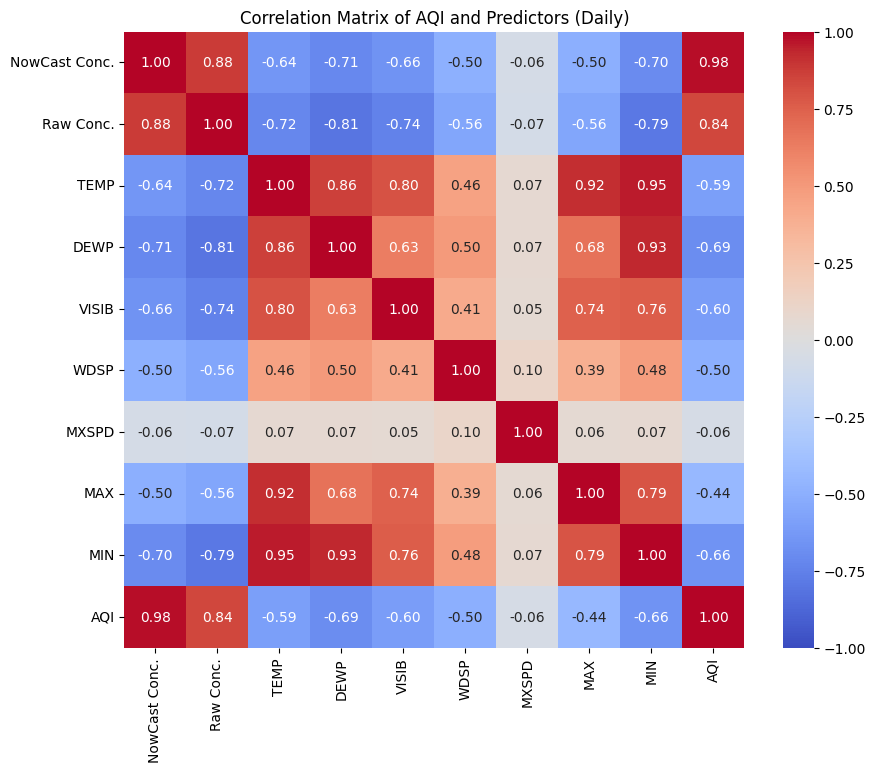

Daily correlation matrix saved as correlation_heatmap_daily.png


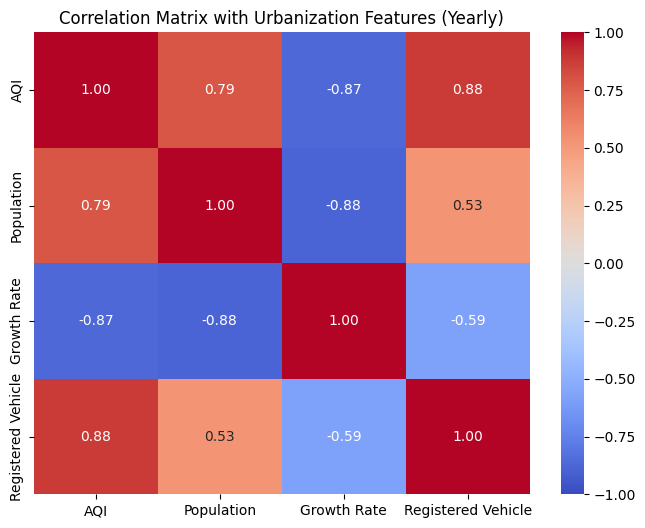

Yearly correlation matrix saved as correlation_heatmap_yearly.png


In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation analysis
def correlation_analysis(daily_df, yearly_df, features, target):
    if daily_df.empty:
        print("No data for correlation analysis.")
        return None
    # Daily data correlation
    corr_matrix = daily_df[features + [target]].corr(method='pearson')
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
    plt.title('Correlation Matrix of AQI and Predictors (Daily)')
    plt.savefig('correlation_heatmap_daily.png')
    plt.show()
    print("Daily correlation matrix saved as correlation_heatmap_daily.png")
    
    # Yearly data correlation with urbanization
    if not yearly_df.empty:
        urban_corr = yearly_df[['AQI', 'Population', 'Growth Rate', 'Registered Vehicle']].corr(method='pearson')
        plt.figure(figsize=(8, 6))
        sns.heatmap(urban_corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
        plt.title('Correlation Matrix with Urbanization Features (Yearly)')
        plt.savefig('correlation_heatmap_yearly.png')
        plt.show()
        print("Yearly correlation matrix saved as correlation_heatmap_yearly.png")
        return corr_matrix, urban_corr
    return corr_matrix, None

# Execute correlation analysis
corr_matrix, urban_corr = correlation_analysis(air_weather_daily, air_weather_urban_yearly, features, target)

## <b>Visualization</b>
Visualizations to explore AQI trends and relationships: a time series plot of AQI and PM2.5 (`aqi_pm25_timeseries.png`), scatter plots of AQI vs. weather features (`aqi_scatter_plots.png`), and a yearly AQI vs. registered vehicles plot (`aqi_vehicles_yearly.png`).

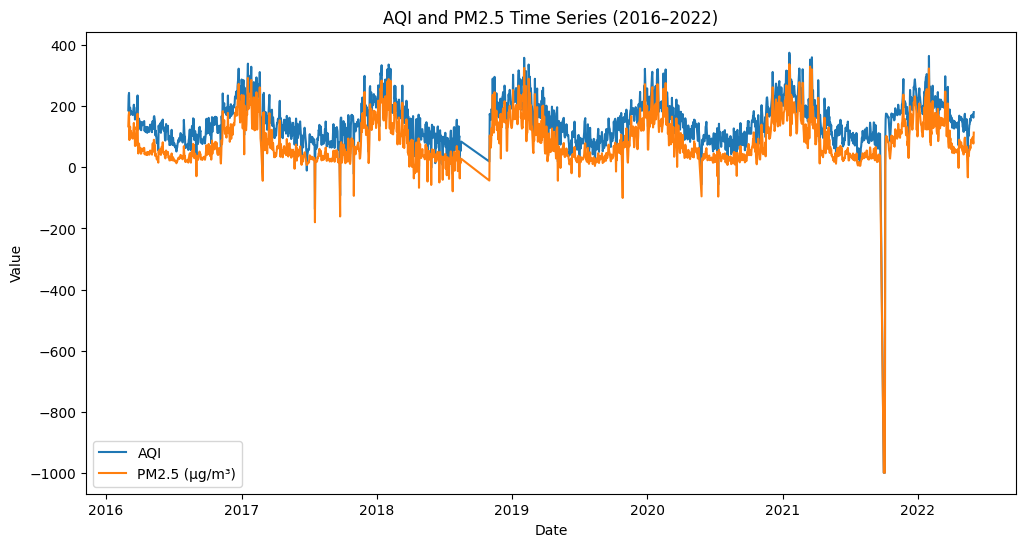

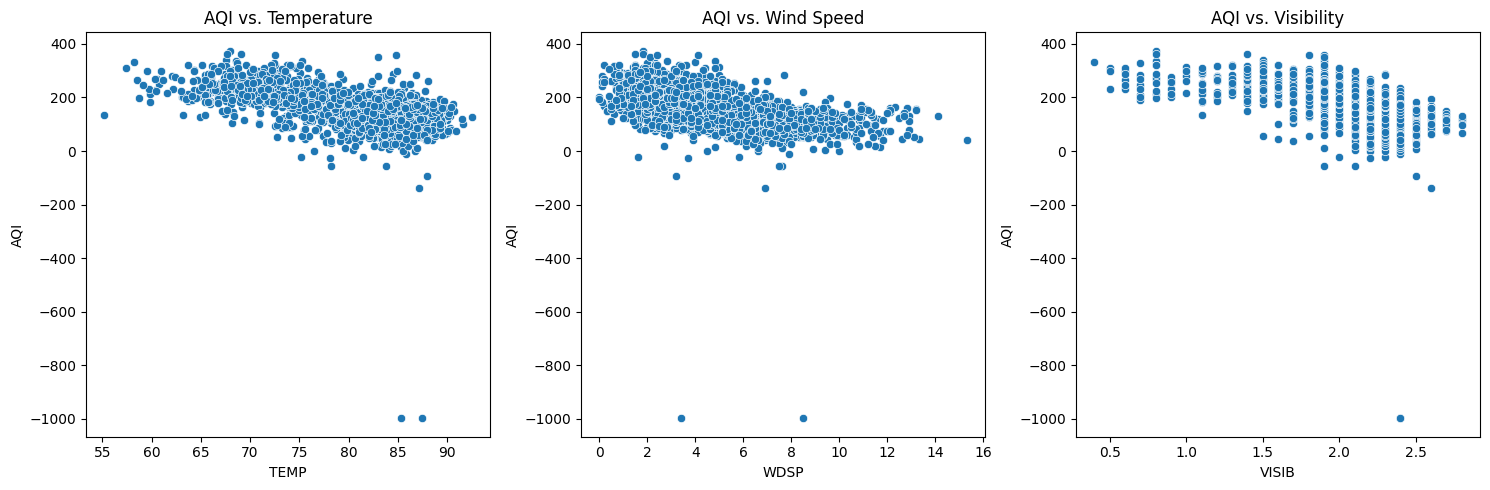

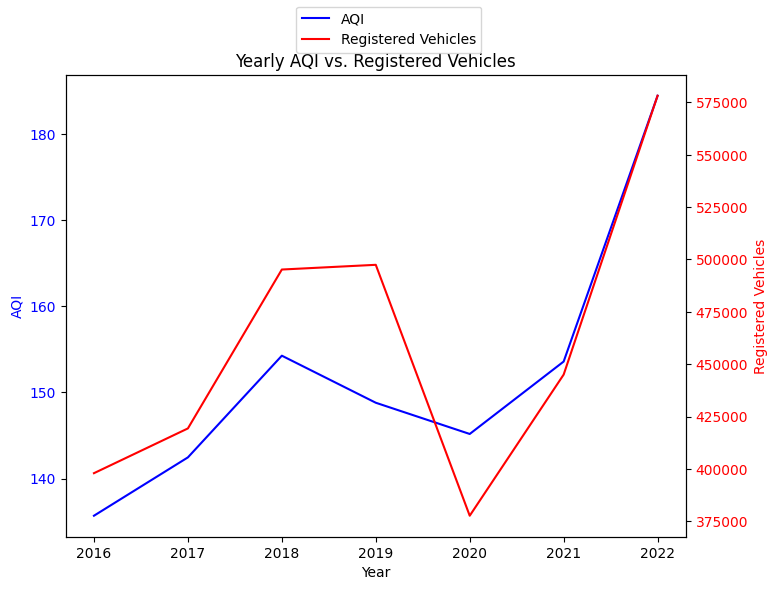

Visualizations saved as aqi_pm25_timeseries.png, aqi_scatter_plots.png, aqi_vehicles_yearly.png


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization
def visualize_data(daily_df, yearly_df, target):
    if daily_df.empty:
        print("No data for visualization.")
        return
    
    # Time series plot
    plt.figure(figsize=(12, 6))
    plt.plot(daily_df['Date'], daily_df[target], label='AQI')
    plt.plot(daily_df['Date'], daily_df['NowCast Conc.'], label='PM2.5 (µg/m³)')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.title('AQI and PM2.5 Time Series (2016–2022)')
    plt.legend()
    plt.savefig('aqi_pm25_timeseries.png')
    plt.show()
    
    # Scatter plots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    sns.scatterplot(data=daily_df, x='TEMP', y=target, ax=axes[0])
    axes[0].set_title('AQI vs. Temperature')
    sns.scatterplot(data=daily_df, x='WDSP', y=target, ax=axes[1])
    axes[1].set_title('AQI vs. Wind Speed')
    sns.scatterplot(data=daily_df, x='VISIB', y=target, ax=axes[2])
    axes[2].set_title('AQI vs. Visibility')
    plt.tight_layout()
    plt.savefig('aqi_scatter_plots.png')
    plt.show()
    
    # Yearly AQI vs. urbanization
    if not yearly_df.empty:
        urban_yearly = yearly_df.groupby('Year').agg({
            'AQI': 'mean',
            'Population': 'mean',
            'Registered Vehicle': 'mean'
        }).reset_index()
        fig, ax1 = plt.subplots(figsize=(8, 6))
        ax1.plot(urban_yearly['Year'], urban_yearly['AQI'], 'b-', label='AQI')
        ax1.set_xlabel('Year')
        ax1.set_ylabel('AQI', color='b')
        ax1.tick_params(axis='y', labelcolor='b')
        ax2 = ax1.twinx()
        ax2.plot(urban_yearly['Year'], urban_yearly['Registered Vehicle'], 'r-', label='Registered Vehicles')
        ax2.set_ylabel('Registered Vehicles', color='r')
        ax2.tick_params(axis='y', labelcolor='r')
        plt.title('Yearly AQI vs. Registered Vehicles')
        fig.legend(loc='upper center')
        plt.savefig('aqi_vehicles_yearly.png')
        plt.show()
    
    print("Visualizations saved as aqi_pm25_timeseries.png, aqi_scatter_plots.png, aqi_vehicles_yearly.png")

# Execute visualization
visualize_data(air_weather_daily, air_weather_urban_yearly, target)

## <b>Data Preprocessing and Train-Test Split</b>
Preprocesses the daily merged dataset by handling missing values, scaling features, and splitting into training (2016–2020) and testing (2021–2022) sets for AQI prediction.

In [22]:
from sklearn.preprocessing import StandardScaler

# Preprocess and split data
def preprocess_and_split(df, features, target, train_years=(2016, 2020), test_years=(2021, 2022)):
    if df.empty:
        print("No data for preprocessing.")
        return None, None, None, None, None
    
    # Filter by years
    train_df = df[df['Year'].between(train_years[0], train_years[1])]
    test_df = df[df['Year'].between(test_years[0], test_years[1])]
    
    # Handle missing values
    train_df = train_df[features + [target]].fillna(train_df.mean(numeric_only=True))
    test_df = test_df[features + [target]].fillna(test_df.mean(numeric_only=True))
    
    # Split features and target
    X_train = train_df[features]
    y_train = train_df[target]
    X_test = test_df[features]
    y_test = test_df[target]
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print("Training set shape:", X_train_scaled.shape)
    print("Testing set shape:", X_test_scaled.shape)
    return X_train_scaled, y_train, X_test_scaled, y_test, scaler

# Execute preprocessing
X_train, y_train, X_test, y_test, scaler = preprocess_and_split(air_weather_daily, features, target)

Training set shape: (1676, 9)
Testing set shape: (498, 9)


## <b>Model Training and Optimization</b>
Three models (XGBoost, Random Forest, LSTM) to predict AQI, optimizes hyperparameters using grid search for XGBoost and Random Forest, and evaluates performance with RMSE, MAE, and R² metrics. The LSTM model uses a simple architecture due to computational constraints.

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import numpy as np
import pandas as pd

# Train and evaluate models
def train_and_evaluate_models(X_train, y_train, X_test, y_test):
    if X_train is None or y_train is None:
        print("No data for model training.")
        return None, None
    
    results = {}
    
    # Random Forest
    rf_params = {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, None]
    }
    rf = RandomForestRegressor(random_state=42)
    rf_grid = GridSearchCV(rf, rf_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    rf_grid.fit(X_train, y_train)
    rf_best = rf_grid.best_estimator_
    rf_pred = rf_best.predict(X_test)
    results['Random Forest'] = {
        'RMSE': np.sqrt(mean_squared_error(y_test, rf_pred)),
        'MAE': mean_absolute_error(y_test, rf_pred),
        'R2': r2_score(y_test, rf_pred),
        'Best Params': rf_grid.best_params_
    }
    
    # XGBoost
    xgb_params = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 6, 9],
        'learning_rate': [0.01, 0.1, 0.2]
    }
    xgb_model = xgb.XGBRegressor(random_state=42)
    xgb_grid = GridSearchCV(xgb_model, xgb_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    xgb_grid.fit(X_train, y_train)
    xgb_best = xgb_grid.best_estimator_
    xgb_pred = xgb_best.predict(X_test)
    results['XGBoost'] = {
        'RMSE': np.sqrt(mean_squared_error(y_test, xgb_pred)),
        'MAE': mean_absolute_error(y_test, xgb_pred),
        'R2': r2_score(y_test, xgb_pred),
        'Best Params': xgb_grid.best_params_
    }
    
    # LSTM
    X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))
    lstm_model = Sequential([
        LSTM(50, activation='relu', input_shape=(1, X_train.shape[1]), return_sequences=True),
        LSTM(50, activation='relu'),
        Dense(1)
    ])
    lstm_model.compile(optimizer='adam', loss='mse')
    lstm_model.fit(X_train_lstm, y_train, epochs=50, batch_size=32, verbose=1)
    lstm_pred = lstm_model.predict(X_test_lstm).flatten()
    results['LSTM'] = {
        'RMSE': np.sqrt(mean_squared_error(y_test, lstm_pred)),
        'MAE': mean_absolute_error(y_test, lstm_pred),
        'R2': r2_score(y_test, lstm_pred),
        'Best Params': 'Default (50 units, 50 epochs, 2-layer LSTM)'
    }
    
    # Print results
    print("\nModel Performance Comparison:")
    for model, metrics in results.items():
        print(f"\n{model}:")
        print(f"RMSE: {metrics['RMSE']:.2f}")
        print(f"MAE: {metrics['MAE']:.2f}")
        print(f"R2: {metrics['R2']:.2f}")
        print(f"Best Parameters: {metrics['Best Params']}")
    
    # Save results
    results_df = pd.DataFrame({
        'Model': [model for model in results.keys()],
        'MAE': [results[model]['MAE'] for model in results.keys()],
        'RMSE': [results[model]['RMSE'] for model in results.keys()],
        'R2': [results[model]['R2'] for model in results.keys()]
    })
    results_df.to_csv('model_results.csv', index=False)
    print("\nModel results saved to model_results.csv")
    
    # Select best model based on RMSE
    best_model = min(results, key=lambda x: results[x]['RMSE'])
    print(f"\nBest Model: {best_model}")
    return results, best_model

# Execute model training
results, best_model = train_and_evaluate_models(X_train, y_train, X_test, y_test)

Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 25881.4199
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 24809.4219
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 18703.0137
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8459.2480
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6505.1787
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5248.2261
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4698.2798
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4200.8394
Epoch 9/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3496.1565
Epoch 10/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3024.0288
Epoch 11/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2733.0715
Epoch 12/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2462.8862
Epoch 13/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2299.0127
Epoch 14/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1987.9158
Epoch 15/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0

## AQI Prediction and Results Visualization
Best-performing model to predict AQI on the test set (2021–2022) and visualizes actual vs. predicted AQI, saving the plot as `prediction_<model>.png`. Results are saved in `model_results.csv` for further analysis.

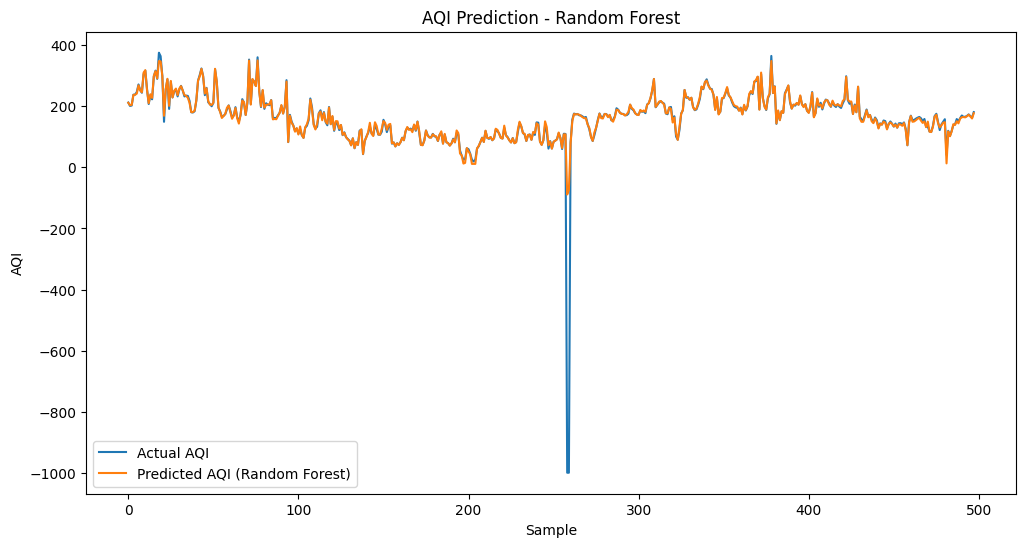

Prediction plot saved as prediction_random_forest.png


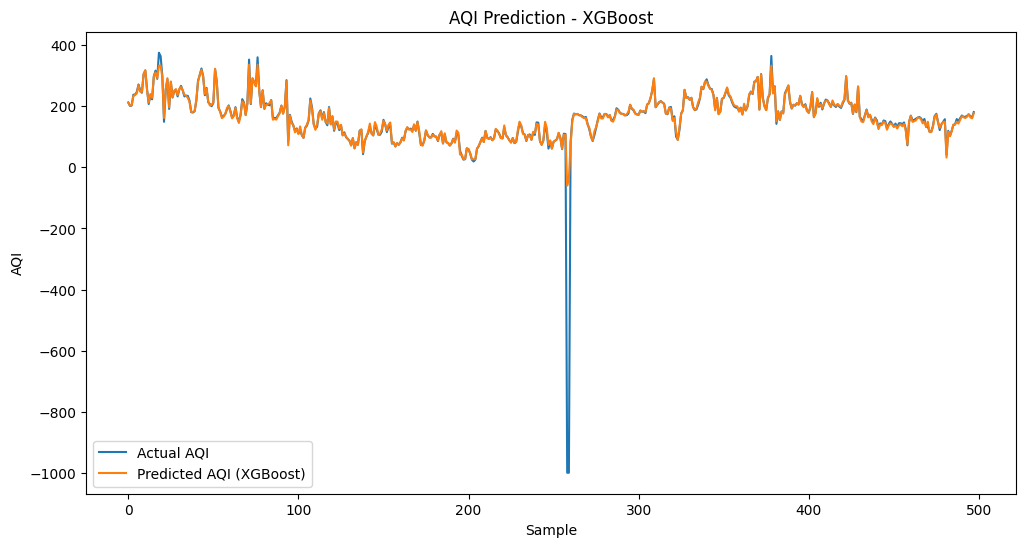

Prediction plot saved as prediction_xgboost.png
Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 25367.7773
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 23912.2031
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 15684.8896
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7857.6646
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6279.0049
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5325.7051
Epoch 7/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 4515.8740
Epoch 8/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3931.6223
Epoch 9/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3405.8228
Epoch 10/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3102.3511
Epoch 11/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2581.9739
Epoch 12/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2368.7979
Epoch 13/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2364.9717
Epoch 14/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 21

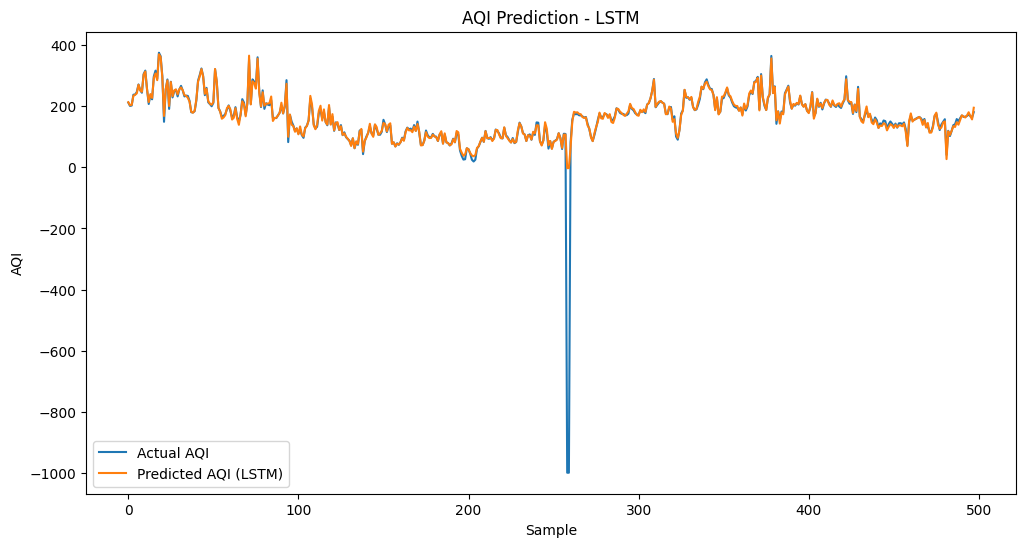

Prediction plot saved as prediction_lstm.png


In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# Visualize predictions and save results
def visualize_and_save_results(y_test, results, best_model):
    if not results:
        print("No model results to visualize.")
        return
    
    # Plot predictions for each model
    for model in results:
        if model == 'Random Forest':
            rf_model = RandomForestRegressor(**results['Random Forest']['Best Params'], random_state=42).fit(X_train, y_train)
            predictions = rf_model.predict(X_test)
        elif model == 'XGBoost':
            xgb_model = xgb.XGBRegressor(**results['XGBoost']['Best Params'], random_state=42).fit(X_train, y_train)
            predictions = xgb_model.predict(X_test)
        else:  # LSTM
            X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
            X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))
            lstm_model = Sequential([
                LSTM(50, activation='relu', input_shape=(1, X_train.shape[1]), return_sequences=True),
                LSTM(50, activation='relu'),
                Dense(1)
            ])
            lstm_model.compile(optimizer='adam', loss='mse')
            lstm_model.fit(X_train_lstm, y_train, epochs=50, batch_size=32, verbose=1)
            predictions = lstm_model.predict(X_test_lstm).flatten()
        
        plt.figure(figsize=(12, 6))
        plt.plot(y_test.values, label='Actual AQI')
        plt.plot(predictions, label=f'Predicted AQI ({model})')
        plt.xlabel('Sample')
        plt.ylabel('AQI')
        plt.title(f'AQI Prediction - {model}')
        plt.legend()
        plt.savefig(f'prediction_{model.lower().replace(" ", "_")}.png')
        plt.show()
        print(f"Prediction plot saved as prediction_{model.lower().replace(' ', '_')}.png")

# Execute visualization
visualize_and_save_results(y_test, results, best_model)